# Left vs right fist decoding from EEG (PhysioNet EEGMMIDB)

**Goal:** from 3 s of 64-channel EEG, predict whether a person moved their left or right fist.

### Final model
| | |
|---|---|
| Model | Filter-bank CSP (six 4 Hz bands, 8–32 Hz) + shrinkage LDA |
| Trained on | Executed (real movement) left/right fist runs 3, 7, 11 · 106 subjects · 4,755 trials |
| Input | 64 channels, 0.5–3.5 s after the cue, 160 Hz |
| Evaluation | Leave-one-subject-out: train on 105 people, test on the one left out |
| Result | 0.626 balanced accuracy on unseen people (AUC 0.727); chance = 0.50 |
| Saved model | Refit on all 106 subjects → `artifacts/fbcsp_model.npz`, used by `predict.py` |
| Caveat | The same model scores 0.64 on pre-cue rest, so part of the signal likely reflects trial order rather than the movement itself (§5.5) |

Adding imagined-movement runs to training did not help (§8), so the final model uses executed runs only.

### Outline
1. Preprocessing: build the dataset and check the signal
2. Splits: what train and test share
3. Models: CSP + LDA, and filter-bank CSP
4. Training
5. Results, significance, controls
6. Additional experiments
7. Final model export
8. Executed vs imagined training data

## 0 · Setup

In [87]:
import sys; sys.path.insert(0, "..")

# Data location and thread limits. Imported first so the limits apply before NumPy loads.
from src.config import DATA_DIR

from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from mne import Epochs, events_from_annotations
from mne.datasets import eegbci
from mne.decoding import CSP
from mne.io import read_raw_edf
from scipy.ndimage import uniform_filter1d
from scipy.stats import binom, wilcoxon
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.pipeline import Pipeline

mne.set_log_level("ERROR")

# Where predictions are saved, and one color per condition shared by every figure.
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)
COLORS = {"rest": "#c9c9c9", "left": "#7f77dd", "right": "#d85a30"}

from scipy.linalg import eigh
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score
import predict   # after sys.path insert

## 1 · Preprocessing
| Step | Choice | Why |
|---|---|---|
| Runs | Real left/right fist movement (runs 3, 7, 11) | Stronger signal than imagined movement |
| Excluded | Subjects 88, 92, 100; subject 89 run 3 | Recorded at 128 Hz instead of 160 Hz; one run has an abnormal length |
| Channels | All 64 | Names standardized (raw files have trailing dots) |
| Filter | 8–30 Hz band-pass | Keeps mu and beta; removes slow drift and 60 Hz power-line noise |
| Labels | T1 → left, T2 → right; rest (T0) dropped | Mapping only valid in left/right runs; code rejects others |
| Window | 0.5–3.5 s after the cue | Skips the brain's brief reaction to the cue; ends before the task block does |
| Baseline correction | None | The model uses signal power, which a constant offset doesn't change |
| Artifact rejection | None | A 150 µV threshold removed 57% of trials and emptied 31 subjects |

### 1.1 Settings

In [88]:
EXECUTED_RUNS = [3, 7, 11]
IMAGINED_RUNS = [4, 8, 12]

# From the dataset audit: these subjects were recorded at 128 Hz, and this run has an anomalous duration.
EXCLUDED_SUBJECTS = {88, 92, 100}
EXCLUDED_RUNS = {(89, 3)}
SUBJECTS = [s for s in range(1, 110) if s not in EXCLUDED_SUBJECTS]

# Mu and beta, where motor desynchronization lives. Also removes drift and 60 Hz line noise.
BAND = (8.0, 30.0)

# Post-cue window: starts after the cue-evoked response (~0.4 s), ends 0.5 s before the task ends.
TMIN, TMAX = 0.5, 3.5

CLASS_NAMES = ("left", "right")   # label 0 = left, 1 = right

### 1.2 Pipeline functions

Four steps, each building on the one before: `load_run` reads one recording, `bandpass` filters it, `epoch_run` cuts it into labeled trials, and `build_dataset` stacks every recording into arrays.

In [89]:
def load_run(subject, run, path=DATA_DIR):
    """Read one EDF and fix the channel names, which ship with trailing dots."""
    fname = eegbci.load_data(subject, [run], path=path, update_path=False, verbose="ERROR")[0]
    raw = read_raw_edf(fname, preload=True, verbose="ERROR")
    eegbci.standardize(raw)
    raw.set_montage("standard_1005")
    return raw


def bandpass(raw, band=BAND):
    """Zero-phase FIR bandpass, applied in place. The one place filter settings live."""
    return raw.filter(*band, method="fir", phase="zero", fir_design="firwin", verbose="ERROR")


def epoch_run(subject, run, tmin=TMIN, tmax=TMAX, band=BAND, path=DATA_DIR):
    """Load one run, bandpass it, and cut it into labeled epochs."""
    # T1/T2 mean different movements in fists-vs-feet runs, so only left/right runs pass.
    if run not in EXECUTED_RUNS + IMAGINED_RUNS:
        raise ValueError(f"run {run} is not a left/right fist run")

    # Filter the continuous recording, not the epochs, so FIR edge transients
    # land outside the window instead of inside it.
    raw = bandpass(load_run(subject, run, path), band)

    # T1 is the left fist, T2 the right. T0 (rest) is not in event_id, so it yields no epochs.
    events, ids = events_from_annotations(raw, verbose="ERROR")
    event_id = {"left": ids["T1"], "right": ids["T2"]}

    return Epochs(raw, events, event_id=event_id, tmin=tmin, tmax=tmax,
                  baseline=None, preload=True, verbose="ERROR")


def build_dataset(subjects, runs, tmin=TMIN, tmax=TMAX, band=BAND, path=DATA_DIR):
    """Stack every run into X, plus the labels and metadata the splits need."""
    chunks, labels, subject_ids, run_ids = [], [], [], []

    for subject in subjects:
        for run in runs:
            if (subject, run) in EXCLUDED_RUNS:
                continue
            epochs = epoch_run(subject, run, tmin, tmax, band, path)

            # Map MNE's internal event codes back to 0 = left, 1 = right.
            code_to_label = {code: CLASS_NAMES.index(name) for name, code in epochs.event_id.items()}

            chunks.append(epochs.get_data(copy=False))
            labels.append(np.array([code_to_label[c] for c in epochs.events[:, 2]]))
            subject_ids.append(np.full(len(epochs), subject))
            run_ids.append(np.full(len(epochs), run))

    return (np.concatenate(chunks).astype(np.float32),
            np.concatenate(labels),
            np.concatenate(subject_ids),
            np.concatenate(run_ids))

### 1.3 Build the dataset

In [90]:
# Load, filter, label and epoch every usable run. Takes about a minute.
# Expect (4755, 64, 481): 3.0 s at 160 Hz, 106 subjects, both classes balanced.
X, y, subjects, runs = build_dataset(SUBJECTS, EXECUTED_RUNS)
print(X.shape, np.bincount(y), len(np.unique(subjects)), "subjects")

# Channel names and electrode positions, identical for every run. Used by figures and channel picks.
info = epoch_run(1, 3).info
ch_names = info.ch_names

(4755, 64, 481) [2384 2371] 106 subjects


### 1.4 Trial structure

Each black bar (our epoch) should sit fully inside a coloured task block, never overlapping rest.

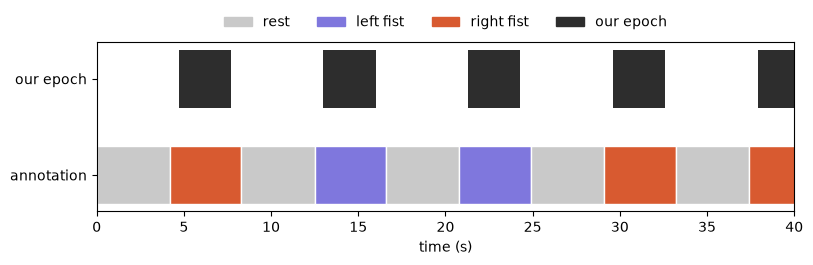

In [53]:
# Subject 1, run 3, first 40 s: task blocks from the annotations (top), the epochs we cut (bottom).
ann = load_run(1, 3).annotations
label = {"T0": "rest", "T1": "left", "T2": "right"}

fig, ax = plt.subplots(figsize=(9, 2.2))
for onset, dur, desc in zip(ann.onset, ann.duration, ann.description):
    ax.barh(0, dur, left=onset, height=0.6, color=COLORS[label[desc]], edgecolor="white")
    if desc != "T0":
        ax.barh(1, TMAX - TMIN, left=onset + TMIN, height=0.6, color="#2d2d2d")

legend = {"rest": COLORS["rest"], "left fist": COLORS["left"], "right fist": COLORS["right"], "our epoch": "#2d2d2d"}
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in legend.values()], legend,
          ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False)
ax.set_yticks([0, 1], ["annotation", "our epoch"])
ax.set(xlim=(0, 40), xlabel="time (s)")
plt.show()

### 1.5 What the bandpass removes

Inside the shaded band the filtered spectrum should match the raw one; outside it, both the low-frequency drift and the 60 Hz line-noise spike should be gone.

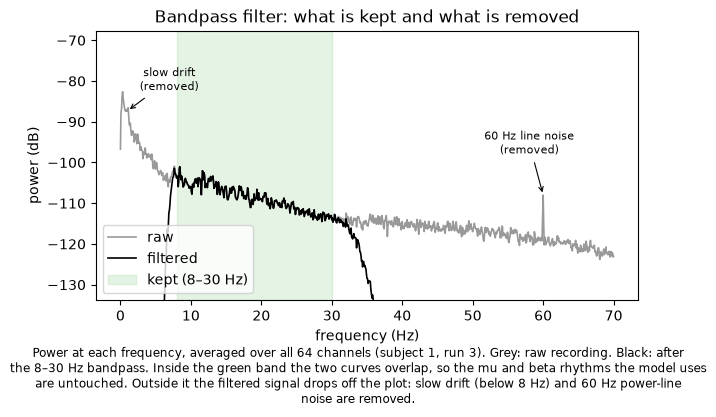

In [54]:
from textwrap import fill

# Subject 1, run 3: average power spectrum across channels, before and after the pipeline's bandpass().
raw = load_run(1, 3)
filt = bandpass(raw.copy())
lo, hi = BAND

spectra = {}
for name, r in [("raw", raw), ("filtered", filt)]:
    psd, freqs = r.compute_psd(fmax=70, verbose="ERROR").get_data(return_freqs=True)
    spectra[name] = 10 * np.log10(psd.mean(axis=0))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(freqs, spectra["raw"], color="#999", lw=1.2, label="raw")
ax.plot(freqs, spectra["filtered"], color="k", lw=1.2, label="filtered")
ax.axvspan(lo, hi, color="tab:green", alpha=0.12, label=f"kept ({lo:.0f}–{hi:.0f} Hz)")

# Clip the y-axis so removed frequencies fall off the plot; label what was removed.
ax.set_ylim(spectra["raw"].min() - 10, spectra["raw"].max() + 15)
for f, text, offset in [(1, "slow drift", (30, 15)), (60, "60 Hz line noise", (-10, 30))]:
    i = np.argmin(np.abs(freqs - f))
    ax.annotate(f"{text}\n(removed)", xy=(f, spectra["raw"][i]), xytext=offset, textcoords="offset points",
                ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))

ax.set(xlabel="frequency (Hz)", ylabel="power (dB)", title="Bandpass filter: what is kept and what is removed")
ax.legend(loc="lower left")

caption = ("Power at each frequency, averaged over all 64 channels (subject 1, run 3). Grey: raw recording. "
           "Black: after the 8–30 Hz bandpass. Inside the green band the two curves overlap, so the mu and beta "
           "rhythms the model uses are untouched. Outside it the filtered signal drops off the plot: slow drift "
           "(below 8 Hz) and 60 Hz power-line noise are removed.")
fig.text(0.5, -0.02, fill(caption, 110), ha="center", va="top", fontsize=8.5)
plt.show()

### 1.6 Choosing the epoch window

The window should cover the period when the movement signal is present and exclude everything else. Movement shows up as a drop in mu/beta power at the motor electrodes, so we track that power across the whole trial.

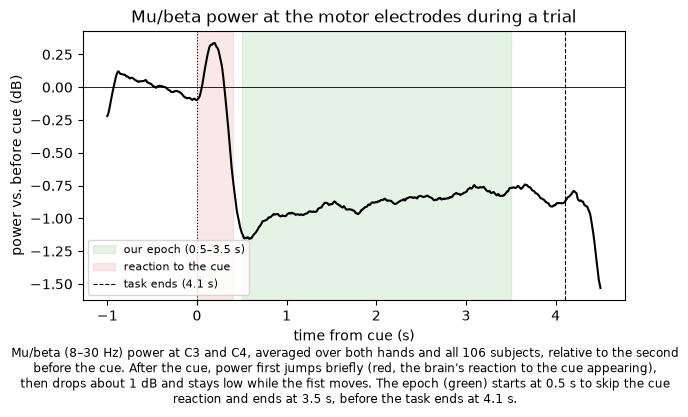

In [55]:
from textwrap import fill

# Mu/beta power at C3 and C4 from 1 s before the cue to 4.5 s after, all subjects and both hands.
PRE, POST = -1.0, 4.5
curves, base_li, task_li = [], [], []

for s in SUBJECTS:
    eps = [epoch_run(s, r, tmin=PRE, tmax=POST) for r in EXECUTED_RUNS if (s, r) not in EXCLUDED_RUNS]
    times = eps[0].times
    data = np.concatenate([e.get_data(picks=["C3", "C4"]) for e in eps])
    right = np.concatenate([e.events[:, 2] == e.event_id["right"] for e in eps])

    # Power in dB, smoothed over 0.25 s, relative to the second before the cue.
    logp = 10 * np.log10(uniform_filter1d(data ** 2, size=40, axis=-1))
    pre, task = times < 0, (times >= TMIN) & (times <= TMAX)
    curves.append((logp - logp[..., pre].mean(axis=(0, 2), keepdims=True)).mean(axis=(0, 1)))

    # Left/right asymmetry before the cue and inside the epoch; reported with the rest control in §5.5.
    lat = logp[:, 1] - logp[:, 0]
    base_li.append(lat[right][:, pre].mean() - lat[~right][:, pre].mean())
    task_li.append(lat[right][:, task].mean() - lat[~right][:, task].mean())

# Task duration from the annotations (identical across runs).
ann = load_run(1, 3).annotations
task_end = np.median(ann.duration[ann.description != "T0"])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(times, np.mean(curves, axis=0), color="k", lw=1.5)
ax.axvspan(TMIN, TMAX, color="tab:green", alpha=0.12, label=f"our epoch ({TMIN}–{TMAX} s)")
ax.axvspan(0, 0.4, color="tab:red", alpha=0.10, label="reaction to the cue")
ax.axvline(0, color="k", lw=0.8, ls=":")
ax.axvline(task_end, color="k", lw=0.8, ls="--", label=f"task ends ({task_end:.1f} s)")
ax.axhline(0, color="k", lw=0.6)
ax.set(xlabel="time from cue (s)", ylabel="power vs. before cue (dB)",
       title="Mu/beta power at the motor electrodes during a trial")
ax.legend(loc="lower left", fontsize=8)

caption = (f"Mu/beta (8–30 Hz) power at C3 and C4, averaged over both hands and all {len(SUBJECTS)} subjects, "
           "relative to the second before the cue. After the cue, power first jumps briefly (red, the brain's "
           "reaction to the cue appearing), then drops about 1 dB and stays low while the fist moves. "
           f"The epoch (green) starts at {TMIN} s to skip the cue reaction and ends at {TMAX} s, "
           f"before the task ends at {task_end:.1f} s.")
fig.text(0.5, -0.02, fill(caption, 110), ha="center", va="top", fontsize=8.5)
plt.show()

### 1.7 Where the left/right difference lives

The classifier works only if left- and right-fist trials differ somewhere on the scalp. This map shows where they differ.

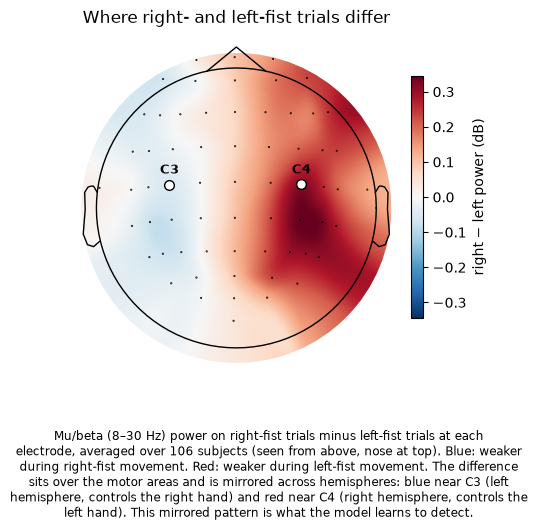

In [56]:
from textwrap import fill

# Right-fist minus left-fist mu/beta power (dB) per electrode, computed per subject then averaged.
logpow = 10 * np.log10((X ** 2).mean(axis=2))
contrast = np.mean([
    logpow[(subjects == s) & (y == 1)].mean(0) - logpow[(subjects == s) & (y == 0)].mean(0)
    for s in np.unique(subjects)
], axis=0)

lim = np.abs(contrast).max()
fig, ax = plt.subplots(figsize=(5, 4.5))
im, _ = mne.viz.plot_topomap(contrast, info, axes=ax, show=False, cmap="RdBu_r", vlim=(-lim, lim),
                             contours=0, mask=np.isin(ch_names, ["C3", "C4"]),
                             mask_params=dict(marker="o", markerfacecolor="w", markeredgecolor="k", markersize=7))

# Label the two motor electrodes directly on the map.
pos = {ch: xy for ch, xy in zip(ch_names, mne.channels.layout._find_topomap_coords(info, picks="eeg"))}
for ch in ("C3", "C4"):
    ax.annotate(ch, pos[ch], xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, weight="bold")

fig.colorbar(im, ax=ax, shrink=0.7, label="right − left power (dB)")
ax.set_title("Where right- and left-fist trials differ")

caption = (f"Mu/beta (8–30 Hz) power on right-fist trials minus left-fist trials at each electrode, averaged over "
           f"{len(np.unique(subjects))} subjects (seen from above, nose at top). Blue: weaker during right-fist movement. "
           "Red: weaker during left-fist movement. The difference sits over the motor areas and is mirrored across "
           "hemispheres: blue near C3 (left hemisphere, controls the right hand) and red near C4 (right hemisphere, "
           "controls the left hand). This mirrored pattern is what the model learns to detect.")
fig.text(0.5, -0.02, fill(caption, 85), ha="center", va="top", fontsize=8.5)
plt.show()

### 1.8 Label check

The dataset documents T1 = left fist, T2 = right fist. If the labels were swapped in any run, the left/right asymmetry from §1.7 would turn negative in that run. It is positive in all three runs, so the labels are consistent.

In [57]:
# Left/right asymmetry per (subject, run): C4 − C3 power in dB, right-fist minus left-fist trials.
c3, c4 = ch_names.index("C3"), ch_names.index("C4")
lat = 10 * np.log10((X[:, c4] ** 2).mean(axis=1) / (X[:, c3] ** 2).mean(axis=1))

li = pd.DataFrame([
    {"subject": s, "run": r, "asymmetry": lat[m & (y == 1)].mean() - lat[m & (y == 0)].mean()}
    for s in np.unique(subjects) for r in EXECUTED_RUNS
    if (m := (subjects == s) & (runs == r)).any()
])

# Averaged over subjects: a swapped run would show a negative mean.
li.groupby("run").asymmetry.agg(mean_dB="mean", share_positive=lambda v: (v > 0).mean()).round(2)

,mean_dB,share_positive
run,,
3,0.31,0.73
7,0.36,0.73
11,0.43,0.79


### 1.9 FBCSP features: trial covariances per band

FBCSP needs the data filtered into several bands. Each band reruns the §1.2 pipeline with only the filter changed, then keeps one 64 × 64 covariance per trial (CSP only ever uses these). Nothing is fitted, so it is safe before the split. The first run takes ~7 minutes; results are cached.

In [23]:
# Bands for each filter-bank model. "csp_cov" is plain CSP (one band) run through the FBCSP code:
# comparing FBCSP against it isolates the effect of the filter bank from the change of implementation.
BANKS = {
    "csp_cov": [(8, 30)],
    "mu_beta": [(8, 13), (13, 30)],
    "fb4": [(8, 12), (12, 16), (16, 20), (20, 24), (24, 28), (28, 32)],
}
MODELS = {"csp_cov": "CSP 8–30 Hz (cov)", "mu_beta": "FBCSP mu + beta", "fb4": "FBCSP 4 Hz bank"}


def trial_covariances(X):
    """One channel-by-channel covariance per epoch: (n_epochs, 64, 64)."""
    return (X @ X.transpose(0, 2, 1)) / X.shape[-1]

In [24]:
# Covariances for every band, cached next to the raw data (gitignored; the file is ~700 MB).
# The file name includes the window, so a new window never reuses old values.
cache = Path(DATA_DIR) / f"band_covs_{TMIN}_{TMAX}.npz"
covs = dict(np.load(cache)) if cache.exists() else {}

for lo, hi in sorted({band for bank in BANKS.values() for band in bank}):
    key = f"{lo}-{hi}"
    if key in covs:
        continue
    if (lo, hi) == BAND:
        Xb = X                                    # 8–30 Hz is already built in §1.3
    else:
        Xb, yb, sb, rb = build_dataset(SUBJECTS, EXECUTED_RUNS, band=(lo, hi))
        # Same epochs in the same order in every band; the splits in §2 rely on it.
        assert np.array_equal(yb, y) and np.array_equal(sb, subjects) and np.array_equal(rb, runs)
    covs[key] = trial_covariances(Xb).astype(np.float32)
    print(f"{key} Hz done")
Xb = None                                         # free the last band's epochs
np.savez(cache, **covs)

# Stack each model's bands: (n_epochs, n_bands, 64, 64).
COV = {m: np.stack([covs[f"{lo}-{hi}"] for lo, hi in bank], axis=1) for m, bank in BANKS.items()}
print({m: C.shape for m, C in COV.items()})

8-12 Hz done
8-13 Hz done
8-30 Hz done
12-16 Hz done
13-30 Hz done
16-20 Hz done
20-24 Hz done
24-28 Hz done
28-32 Hz done
{'csp_cov': (4755, 1, 64, 64), 'mu_beta': (4755, 2, 64, 64), 'fb4': (4755, 6, 64, 64)}


## 2 · Splits

Same task and same model throughout. The only thing that changes between splits is **what the training and test data have in common**. Splits are only defined here; nothing is trained until §4.

| Split | Train and test share | Claim it supports |
|---|---|---|
| Random epochs | Subjects and recordings | Leakage reference: what a pooled model gains from having seen the person |
| New subject | Nothing (leave-one-subject-out) | **Headline**: works on a person we never recorded |
| Calibrated user | The subject, but not the recording (leave-one-run-out, one model per subject) | Works for a user who records calibration data first |

In [25]:
def random_split(y):
    """5 folds, stratified by class, ignoring who each epoch came from."""
    return list(StratifiedKFold(5, shuffle=True, random_state=0).split(np.zeros(len(y)), y))


def new_subject_split(subjects):
    """One fold per subject: that subject's epochs are the test set, everyone else trains."""
    return list(LeaveOneGroupOut().split(subjects, groups=subjects))


def calibrated_split(subjects, runs):
    """Within each subject, train on two runs and test on the third. Folds never mix subjects."""
    folds = []
    for s in np.unique(subjects):
        idx = np.flatnonzero(subjects == s)
        for train, test in LeaveOneGroupOut().split(idx, groups=runs[idx]):
            folds.append((idx[train], idx[test]))
    return folds


SPLITS = {
    "random": random_split(y),
    "new_subject": new_subject_split(subjects),
    "calibrated_user": calibrated_split(subjects, runs),
}
NAMES = {"random": "random epochs", "new_subject": "new subject", "calibrated_user": "calibrated user"}

Sanity check before training. Expected: every epoch tested exactly once in every split; **shared subjects** of 1 / 0 / 1 and **shared recordings** of about 1 / 0 / 0.

In [26]:
def describe(folds):
    """What train and test have in common, as the fraction of test epochs affected, averaged over folds."""
    recording = subjects * 100 + runs          # one id per (subject, run) recording
    tested = np.sort(np.concatenate([te for _, te in folds]))
    return {
        "folds": len(folds),
        "train epochs": round(np.mean([len(tr) for tr, _ in folds])),
        "test epochs": round(np.mean([len(te) for _, te in folds])),
        "shared subjects": round(np.mean([np.isin(subjects[te], subjects[tr]).mean() for tr, te in folds]), 2),
        "shared recordings": round(np.mean([np.isin(recording[te], recording[tr]).mean() for tr, te in folds]), 2),
        "each epoch tested once": np.array_equal(tested, np.arange(len(y))),
    }

pd.DataFrame({NAMES[k]: describe(v) for k, v in SPLITS.items()}).T

,folds,train epochs,test epochs,shared subjects,shared recordings,each epoch tested once
random epochs,5,3804,951,1.0,1.0,True
new subject,106,4710,45,0.0,0.0,True
calibrated user,317,30,15,1.0,0.0,True


**Splits measure performance; they don't produce the final model.** In every split, a fresh model is trained per fold, scored on that fold's test set, and discarded. The model we ship (§7) is trained once on all training subjects. Its expected accuracy on a new person is the **new-subject** score, because that split reproduces the same situation: train on a group, predict someone outside it.

## 3 · Models

**Final model: filter-bank CSP (six 4 Hz bands) + shrinkage LDA.** The plain CSP model below is the baseline it is compared against in §5.

### Baseline: CSP + shrinkage LDA

**CSP (common spatial patterns)** learns 6 spatial filters, each a weighted sum of the 64 electrodes. Three are chosen so their output has much more power on left-fist trials than right, and three the reverse. Because the data is band-passed to 8–30 Hz, this power is mu/beta power, so CSP learns the mirrored C3/C4 pattern from §1.7 automatically. Each trial becomes 6 numbers (the log power of each filter's output), and **LDA** draws a straight-line boundary between left and right in that 6-number space.

Why this model:
- **Few parameters.** The calibrated-user split trains on only ~30 trials per fold.
- **Nothing to tune.** LDA's shrinkage (regularization) is computed directly from the training data (Ledoit–Wolf), so there is no tuning loop that could leak test data.

`make_model()` returns a fresh, unfitted pipeline and is called once per fold.

In [13]:
def make_model(n_components=6):
    """Fresh CSP + shrinkage LDA. n_components can't exceed the number of channels."""
    return Pipeline([
        ("csp", CSP(n_components=n_components, log=True)),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])

### Final model: filter-bank CSP (FBCSP)

The mu/beta pattern differs from person to person: some people's movement signal is strongest at 12 Hz, others' at 20 Hz. FBCSP splits the signal into narrow frequency bands and fits a separate CSP in each, so every band gets its own spatial filters. The features from all bands are joined (6 bands × 6 filters = 36 features), and LDA learns how much each band matters.

| | |
|---|---|
| Bands | Six 4 Hz bands: 8–12, 12–16, 16–20, 20–24, 24–28, 28–32 Hz |
| Filters | 6 per band (3 favouring each class) → 36 features |
| Classifier | Shrinkage LDA |

This is a simplified version of the original FBCSP (Ang et al., 2008), which adds a mutual-information step to select features. We skip it: shrinkage LDA handles 36 features, and every extra fitted step is one more thing that must stay inside the training fold.

**Implementation.** CSP only needs each trial's 64 × 64 channel covariance matrix, so these are computed once (§1.9) instead of refiltering the data in every fold. Per band, the filters **w** are the solutions of a generalized eigenvalue problem. The eigenvalue for a filter equals its left-trial variance divided by its total variance, and we keep the 3 filters with the lowest values and the 3 with the highest. This is the same method as MNE's CSP, with two small differences (how covariance is estimated and how filters are ranked); §5.4 checks that the two give closely matching results.

**Model choice.** Four models are compared in §5.4, and this one was chosen because it scored highest on the new-subject split. Choosing on the same scores we report makes the headline number slightly optimistic, although the gain over plain CSP is highly significant.

In [64]:
from scipy.linalg import eigh
from sklearn.base import BaseEstimator, TransformerMixin


class FilterBankCSP(BaseEstimator, TransformerMixin):
    """CSP fitted separately in each frequency band, working on precomputed trial covariances.

    Input C has shape (n_trials, n_bands, n_channels, n_channels). With one band this is ordinary CSP.
    n_components // 2 filters are kept from each end of the eigenvalue spectrum, per band.
    """

    def __init__(self, n_components=6):
        self.n_components = n_components

    def fit(self, C, y):
        k = self.n_components // 2
        self.filters_ = []
        for b in range(C.shape[1]):
            # Average covariance of each class in this band (training trials only).
            c_left = C[y == 0, b].mean(axis=0, dtype=np.float64)
            c_right = C[y == 1, b].mean(axis=0, dtype=np.float64)

            # A tiny ridge keeps the denominator invertible if the data is slightly rank-deficient.
            total = c_left + c_right
            total += 1e-6 * np.trace(total) / len(total) * np.eye(len(total))

            # Eigenvalues come back ascending: first k favour right trials, last k favour left.
            _, vecs = eigh(c_left, total)
            self.filters_.append(np.hstack([vecs[:, :k], vecs[:, -k:]]))
        return self

    def transform(self, C):
        # Log variance of each filter's output, log(w' C w), for every trial, band and filter.
        return np.hstack([np.log(((C[:, b] @ W) * W).sum(axis=1))
                          for b, W in enumerate(self.filters_)])


def make_fbcsp(n_components=6):
    """Fresh filter-bank CSP + shrinkage LDA. The number of bands comes from the input."""
    return Pipeline([
        ("csp", FilterBankCSP(n_components=n_components)),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])

## 4 · Training (evaluation only)

These models measure performance; none of them is kept. For each fold: build a fresh model, fit it on the training trials only, predict the test trials, discard the model. Across a split, every trial is predicted exactly once, by a model that never saw it. Only predictions are saved, so §5 can be rerun without retraining.

| Model | Input | Role |
|---|---|---|
| CSP 8–30 Hz (MNE) | Band-passed epochs `X` | Baseline |
| CSP 8–30 Hz (cov) | 1 band of covariances | Same model in our code; isolates the filter-bank effect |
| FBCSP mu + beta | 2 bands | Comparison |
| FBCSP, six 4 Hz bands | 6 bands | **Final model** |

All inputs come from executed runs 3, 7, 11 of 106 subjects. The final model is trained once, separately, in §7.

**Runtime.** The MNE baseline's new-subject split takes about 15 minutes (3 workers at 2–3 GB each, so keep `n_jobs=3` on 16 GB; a "worker stopped" warning means joblib restarted a worker and doesn't affect results). The FBCSP models use precomputed covariances and take under a minute in total.

In [65]:
def fit_predict(make, X, y, train, test):
    """One fold: fit a fresh model on train, return predictions for test."""
    mne.set_log_level("ERROR")   # workers are separate processes and don't inherit the setting
    return make().fit(X[train], y[train]).predict(X[test])


def out_of_fold(make, X, y, folds, n_jobs=3):
    """Predict every trial once, each by a model trained without it."""
    preds = Parallel(n_jobs=n_jobs)(delayed(fit_predict)(make, X, y, tr, te) for tr, te in folds)
    pred = np.full(len(y), -1)
    for (_, te), p in zip(folds, preds):
        pred[te] = p
    assert (pred >= 0).all(), "some trials were never predicted"
    return pred

In [59]:
# CSP baseline on every split. Loads saved predictions if present; delete the file to retrain (~15 min).
path = RESULTS / "preds_csp_lda.npz"
if path.exists():
    preds = dict(np.load(path))
else:
    preds = {name: out_of_fold(make_model, X, y, folds) for name, folds in SPLITS.items()}
    np.savez(path, **preds)

<h3> FBCSP Models

In [66]:
# Every filter-bank model on every split, saved separately from the CSP baseline. Under a minute.
path = RESULTS / "preds_fbcsp.npz"
if path.exists():
    fb_preds = dict(np.load(path))
else:
    fb_preds = {f"{model}__{split}": out_of_fold(make_fbcsp, COV[model], y, folds, n_jobs=1)
                for model in MODELS for split, folds in SPLITS.items()}
    np.savez(path, **fb_preds)

## 5 · Evaluation and results

All metrics are computed **per subject**, then summarized across subjects. One person's trials are correlated with each other, so subjects, not trials, are the independent units. A per-subject mean also answers the practical question: what would a typical new person get?

| # | Metric | What it is, simply | Why we use it |
|---|---|---|---|
| 1 | **Balanced accuracy** | Share of left trials called left and right trials called right, averaged. Chance = 0.50. Reported as a mean with a 95% confidence interval. | The most interpretable number: how often the model is right for a new person. Averaging the two hands stops a model from scoring well by always guessing one hand. |
| 2 | **ROC-AUC** | Probability that a random right-fist trial gets a higher "right" score than a random left-fist trial. Chance = 0.50. | The standard two-class BCI benchmark metric (MOABB). It ignores the decision threshold, which for a new person is learned from other people. |
| 3 | **Subjects above chance** | With ~45 trials, random guessing scores above 0.622 for 5% of people by luck. We count who beats 0.622. | Shows whether the mean comes from most people or a few. |
| 4 | **Label permutation** | Shuffle labels within each subject, rerun everything. Must give ≈ 0.50. | Proves the pipeline doesn't leak. |
| 5 | **Trial-order control** | Hands alternate 75% of the time, so the next hand is partly predictable from the last. We compare accuracy on trials that repeat vs switch hands. | Tests whether the model decodes the movement itself or the trial order. |

Two models or splits are compared with a **paired Wilcoxon signed-rank test** on per-subject scores: it compares each person against themselves and doesn't assume normally distributed scores (ours are bimodal).

In [69]:
# Final model and the chance bound used throughout §5.
HEADLINE = "fb4"
ALL_MODELS = {"csp_mne": "CSP 8–30 Hz (MNE)", **MODELS}

# With ~45 trials, random guessing still scores above this for 5% of subjects.
n_trials = int(pd.Series(subjects).value_counts().median())
chance95 = binom.ppf(0.95, n_trials, 0.5) / n_trials
print(f"95% chance bound at {n_trials} trials: {chance95:.3f}")


def per_subject(pred, y, subjects):
    """Balanced accuracy for each subject."""
    return pd.Series({s: balanced_accuracy_score(y[subjects == s], pred[subjects == s])
                      for s in np.unique(subjects)})


def per_subject_auc(scores, y, subjects):
    """ROC-AUC for each subject, from continuous classifier scores."""
    return pd.Series({s: roc_auc_score(y[subjects == s], scores[subjects == s])
                      for s in np.unique(subjects)})


def out_of_fold_scores(make, C, y, folds):
    """Continuous LDA scores for every trial, each from a model trained without it (needed for AUC)."""
    scores = np.zeros(len(y))
    for train, test in folds:
        scores[test] = make().fit(C[train], y[train]).decision_function(C[test])
    return scores


def ci95(scores, n_boot=10_000):
    """95% confidence interval of the mean, resampling subjects."""
    boot = np.random.default_rng(0).choice(np.asarray(scores), (n_boot, len(scores))).mean(axis=1)
    return np.percentile(boot, [2.5, 97.5])


# Per-subject balanced accuracy for every (model, split) pair.
fb_scores = {tuple(k.split("__")): per_subject(p, y, subjects) for k, p in fb_preds.items()}
fb_scores.update({("csp_mne", split): per_subject(p, y, subjects) for split, p in preds.items()})

95% chance bound at 45 trials: 0.622


### 5.1 Main result

Metrics 1–3 for the final model on each split. **New subject is the headline**: it is the situation the final model is used in. The other two rows show whether having seen the person (random epochs) or training a model just for them (calibrated user) helps.

In [70]:
# Metrics 1–3 for the final model on every split. AUC needs continuous scores, so folds are refit (~40 s).
table = {}
for split, folds in SPLITS.items():
    acc = fb_scores[(HEADLINE, split)]
    auc = per_subject_auc(out_of_fold_scores(make_fbcsp, COV[HEADLINE], y, folds), y, subjects)
    lo, hi = ci95(acc)
    table[NAMES[split]] = {"balanced accuracy": f"{acc.mean():.3f}", "95% CI": f"{lo:.3f}–{hi:.3f}",
                           "AUC": f"{auc.mean():.3f}", "subjects above chance": f"{(acc > chance95).mean():.0%}"}
display(pd.DataFrame(table).T)

# Do the other splits differ from new subject? Paired Wilcoxon across subjects.
base = fb_scores[(HEADLINE, "new_subject")]
for split in ("random", "calibrated_user"):
    d = fb_scores[(HEADLINE, split)] - base
    print(f"{NAMES[split]} − new subject: median {d.median():+.3f}, p = {wilcoxon(d).pvalue:.2g}")

,balanced accuracy,95% CI,AUC,subjects above chance
random epochs,0.609,0.589–0.630,0.677,47%
new subject,0.626,0.606–0.646,0.727,46%
calibrated user,0.640,0.618–0.664,0.698,46%


random epochs − new subject: median -0.022, p = 0.055
calibrated user − new subject: median +0.008, p = 0.55


### 5.2 How results vary between people

A mean hides how many people the model actually works for. This shows one score per new subject.

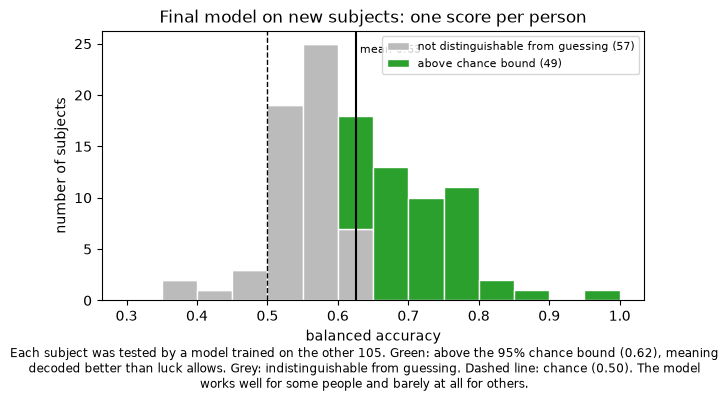

In [71]:
# Per-subject accuracy of the final model on new subjects, split at the chance bound.
acc = fb_scores[(HEADLINE, "new_subject")]
above = acc > chance95

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist([acc[~above], acc[above]], bins=np.arange(0.3, 1.01, 0.05), stacked=True,
        color=["#bbb", "tab:green"], edgecolor="white",
        label=[f"not distinguishable from guessing ({(~above).sum()})", f"above chance bound ({above.sum()})"])
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.axvline(acc.mean(), color="k", lw=1.5)
ax.text(acc.mean(), ax.get_ylim()[1] * 0.95, f" mean {acc.mean():.2f}", fontsize=8, va="top")
ax.set(xlabel="balanced accuracy", ylabel="number of subjects", title="Final model on new subjects: one score per person")
ax.legend(fontsize=8)

caption = (f"Each subject was tested by a model trained on the other {len(acc) - 1}. Green: above the 95% chance "
           f"bound ({chance95:.2f}), meaning decoded better than luck allows. Grey: indistinguishable from guessing. "
           "Dashed line: chance (0.50). The model works well for some people and barely at all for others.")
fig.text(0.5, -0.02, fill(caption, 110), ha="center", va="top", fontsize=8.5)
plt.show()

### 5.3 Model comparison

Four models on the new-subject split. Each is compared per subject against **CSP 8–30 Hz (cov)**, plain CSP run through the same code as FBCSP, so any difference comes from the filter bank alone. The first two rows are the same model in two implementations and should be close.

In [72]:
# Every model on new subjects, each compared per subject against plain CSP from the same code.
base = fb_scores[("csp_cov", "new_subject")]
table = {}
for model, label in ALL_MODELS.items():
    acc = fb_scores[(model, "new_subject")]
    d = acc - base
    table[label] = {"balanced accuracy": f"{acc.mean():.3f}", "subjects above chance": f"{(acc > chance95).mean():.0%}",
                    "vs CSP (cov)": "reference" if model == "csp_cov" else f"{d.median():+.3f} (p = {wilcoxon(d).pvalue:.2g})"}
pd.DataFrame(table).T

,balanced accuracy,subjects above chance,vs CSP (cov)
CSP 8–30 Hz (MNE),0.583,28%,+0.000 (p = 0.92)
CSP 8–30 Hz (cov),0.583,25%,reference
FBCSP mu + beta,0.609,42%,+0.020 (p = 0.0015)
FBCSP 4 Hz bank,0.626,46%,+0.045 (p = 3.2e-07)


### 5.4 Control: label permutation

Shuffle left/right labels within each subject and rerun the full new-subject evaluation. With the labels meaningless, accuracy must fall to 0.50; anything higher would mean information leaks from test to training.

In [73]:
# 10 shuffles of the full new-subject evaluation, ~6 min.
rng = np.random.default_rng(0)
null = []
for _ in range(10):
    y_perm = y.copy()
    for s in np.unique(subjects):
        m = subjects == s
        y_perm[m] = rng.permutation(y[m])
    pred = out_of_fold(make_fbcsp, COV[HEADLINE], y_perm, SPLITS["new_subject"], n_jobs=1)
    null.append(per_subject(pred, y_perm, subjects).mean())

print(f"real labels:     {fb_scores[(HEADLINE, 'new_subject')].mean():.3f}")
print(f"shuffled labels: {np.mean(null):.3f}   (highest of 10: {max(null):.3f})")

real labels:     0.626
shuffled labels: 0.502   (highest of 10: 0.510)


### 5.5 Control: trial order

The rest period before each cue contains no movement, and the subject doesn't yet know which hand is next, so a model decoding movement should score 0.50 there. It doesn't: the hands alternate 75% of the time, so the next hand is partly predictable from the last one.

The second cell measures how much the final model relies on this. On trials that **switch** hands, trial order and movement point to the same answer; on trials that **repeat** a hand, they point to opposite answers. A model decoding only the movement scores the same on both; a model relying on trial order scores high on switch trials and low on repeat trials.

In [74]:
# The final model trained and tested on rest periods (-3.4 to -0.8 s before the cue), labeled with the
# upcoming hand. Rebuilds the data once per band, ~6 min.
rest = []
for lo, hi in BANKS[HEADLINE]:
    Xr, yr, sr, _ = build_dataset(SUBJECTS, EXECUTED_RUNS, tmin=-3.4, tmax=-0.8, band=(lo, hi))
    rest.append(trial_covariances(Xr).astype(np.float32))
    del Xr
rest_acc = per_subject(out_of_fold(make_fbcsp, np.stack(rest, axis=1), yr, new_subject_split(sr), n_jobs=1), yr, sr)

same_run = (subjects[1:] == subjects[:-1]) & (runs[1:] == runs[:-1])
print(f"rest periods (should be 0.50): {rest_acc.mean():.3f}")
print(f"trials repeating the previous hand: {(y[1:] == y[:-1])[same_run].mean():.0%} (50% if random)")

rest periods (should be 0.50): 0.636
trials repeating the previous hand: 25% (50% if random)


In [76]:
# Mark each trial as repeat or switch relative to the previous trial in the same run (first trials excluded).
has_prev = np.r_[False, (subjects[1:] == subjects[:-1]) & (runs[1:] == runs[:-1])]
repeat = has_prev & np.r_[False, y[1:] == y[:-1]]
switch = has_prev & ~repeat

# Plain accuracy per subject on each trial type (repeat trials can be all one hand, so balanced accuracy won't work).
correct = fb_preds[f"{HEADLINE}__new_subject"] == y
acc = pd.DataFrame({name: pd.Series({s: correct[m & (subjects == s)].mean() for s in np.unique(subjects)})
                    for name, m in (("switch", switch), ("repeat", repeat))})

display(pd.DataFrame({"trials": [switch.sum(), repeat.sum()], "accuracy": acc.mean().round(3).values},
                     index=["switch hands", "repeat hand"]))
d = (acc["repeat"] - acc["switch"]).dropna()
print(f"repeat − switch, per subject: median {d.median():+.3f}, p = {wilcoxon(d).pvalue:.2g}")
print(f"repeat trials vs 0.50: p = {wilcoxon(acc['repeat'].dropna() - 0.5).pvalue:.2g}")

,trials,accuracy
switch hands,3349,0.635
repeat hand,1089,0.607


repeat − switch, per subject: median -0.030, p = 0.09
repeat trials vs 0.50: p = 1.3e-09


**Result.** Accuracy is 0.635 on switch trials and 0.607 on repeat trials. On repeat trials, trial order points to the wrong hand, so a model relying on it would score below 0.50; 0.607 means the model mostly decodes the current movement. The 0.03 gap is not significant (p = 0.09), so trial order contributes at most a few points to the headline. The shortcut exists in the data (the rest model finds it), but the task window sits far enough from the previous trial that the final model barely uses it.

<h1> -----------------------------------------------------------------------------------------------------------------------------------

## 6 · Additional experiments

Two follow-up questions about the final model, both on the new-subject split.

### 6.1 Which frequencies carry the left/right signal?

Plain CSP run on each 4 Hz band alone. This shows where the information sits, and why combining bands (the final model) beats any single band.

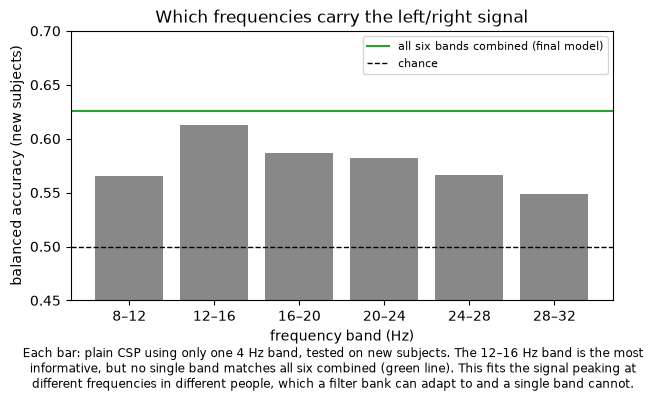

In [77]:
# Plain CSP on each 4 Hz band alone, new-subject split. ~30 s.
band_acc = {}
for lo, hi in BANKS[HEADLINE]:
    C = covs[f"{lo}-{hi}"][:, None]      # one band: (n_trials, 1, 64, 64)
    pred = out_of_fold(make_fbcsp, C, y, SPLITS["new_subject"], n_jobs=1)
    band_acc[f"{lo}–{hi}"] = per_subject(pred, y, subjects).mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(list(band_acc), list(band_acc.values()), color="#888")
ax.axhline(fb_scores[(HEADLINE, "new_subject")].mean(), color="tab:green", lw=1.5, label="all six bands combined (final model)")
ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
ax.set(xlabel="frequency band (Hz)", ylabel="balanced accuracy (new subjects)", ylim=(0.45, 0.70),
       title="Which frequencies carry the left/right signal")
ax.legend(fontsize=8, loc="upper right")

caption = ("Each bar: plain CSP using only one 4 Hz band, tested on new subjects. The 12–16 Hz band is the most "
           "informative, but no single band matches all six combined (green line). This fits the signal peaking at "
           "different frequencies in different people, which a filter bank can adapt to and a single band cannot.")
fig.text(0.5, -0.02, fill(caption, 110), ha="center", va="top", fontsize=8.5)
plt.show()

### 6.2 Executed vs imagined training data

A real BCI user imagines movement rather than performing it. Would the model do better on imagined movement if trained on imagined runs (4, 8, 12), or on both? Each training set is tested on a new subject's executed and imagined trials (leave-one-subject-out).

In [78]:
# Imagined runs through the same pipeline and bands. Run 104-8 has an anomalous duration (dataset audit).
EXCLUDED_RUNS.add((104, 8))
cache_im = Path(DATA_DIR) / f"band_covs_imagined_{TMIN}_{TMAX}.npz"

if cache_im.exists():
    d = np.load(cache_im)
    COV_im, y_im, subjects_im = d["cov"], d["y"], d["subjects"]
else:
    bands = []
    for lo, hi in BANKS[HEADLINE]:
        Xb, y_im, subjects_im, _ = build_dataset(SUBJECTS, IMAGINED_RUNS, band=(lo, hi))
        bands.append(trial_covariances(Xb).astype(np.float32))
    del Xb
    COV_im = np.stack(bands, axis=1)
    np.savez(cache_im, cov=COV_im, y=y_im, subjects=subjects_im)

print(f"imagined: {len(y_im)} trials from {len(np.unique(subjects_im))} subjects")

imagined: 4755 trials from 106 subjects


In [79]:
# For each subject: train three models on everyone else, test each on this subject's executed and imagined trials. ~2 min.
C_ex = COV[HEADLINE]
rows = []
for s in np.unique(subjects):
    tr_ex, tr_im = subjects != s, subjects_im != s
    train = {
        "executed": (C_ex[tr_ex], y[tr_ex]),
        "imagined": (COV_im[tr_im], y_im[tr_im]),
        "both": (np.concatenate([C_ex[tr_ex], COV_im[tr_im]]), np.concatenate([y[tr_ex], y_im[tr_im]])),
    }
    test = {"executed": (C_ex[~tr_ex], y[~tr_ex]), "imagined": (COV_im[~tr_im], y_im[~tr_im])}

    row = {"subject": s}
    for tr_name, (C_tr, y_tr) in train.items():
        model = make_fbcsp().fit(C_tr, y_tr)
        for te_name, (C_te, y_te) in test.items():
            row[(tr_name, te_name)] = balanced_accuracy_score(y_te, model.predict(C_te))
    rows.append(row)

transfer = pd.DataFrame(rows).set_index("subject")
transfer.columns = pd.MultiIndex.from_tuples(transfer.columns, names=["trained on", "tested on"])
display(transfer.mean().unstack().round(3))

# On imagined test trials (the BCI-relevant case), does either alternative beat training on executed?
im = transfer.xs("imagined", level="tested on", axis=1)
for alt in ("imagined", "both"):
    d = im[alt] - im["executed"]
    print(f"tested on imagined, trained on {alt} − executed: median {d.median():+.3f}, p = {wilcoxon(d).pvalue:.2g}")

tested on,executed,imagined
trained on,,
both,0.635,0.630
executed,0.626,0.622
imagined,0.611,0.621


tested on imagined, trained on imagined − executed: median +0.000, p = 0.98
tested on imagined, trained on both − executed: median +0.011, p = 0.2


**Result.** A model trained on executed movement works almost as well on a new person's *imagined* movement (0.622) as on their executed movement (0.626). Training on imagined runs or on both gives no significant improvement, so the final model uses executed runs only.

### 6.3 How many channels are needed?

The final model uses all 64 electrodes, while many motor-imagery systems use far fewer. Fewer channels means fewer parameters to estimate, but also less for CSP to combine. Each channel set is run through the same FBCSP model on the new-subject split.

In [83]:
# The final model restricted to smaller channel sets, new-subject split. Covariances are just sliced. ~1 min.
def pick(names):
    """Channel indices by name, case-insensitive (EEGMMIDB naming is inconsistent)."""
    lookup = {c.lower(): i for i, c in enumerate(ch_names)}
    return [lookup[n.lower()] for n in names]


CHANNEL_SETS = {
    "64 (all)": list(range(len(ch_names))),
    "9 (motor strip)": pick(["FC3", "FC1", "FCz", "FC2", "FC4", "C3", "Cz", "C4", "CPz"]),
    "3 (C3, Cz, C4)": pick(["C3", "Cz", "C4"]),
    "3 (occipital)": pick(["O1", "Oz", "O2"]),
}

rows = []
for name, idx in CHANNEL_SETS.items():
    C = COV[HEADLINE][:, :, idx][:, :, :, idx]        # same covariances, restricted to these channels
    make = partial(make_fbcsp, n_components=min(6, len(idx)))
    acc = per_subject(out_of_fold(make, C, y, SPLITS["new_subject"], n_jobs=1), y, subjects)
    rows.append({"channels": name, "balanced accuracy": round(acc.mean(), 3),
                 "subjects above chance": f"{(acc > chance95).mean():.0%}"})

pd.DataFrame(rows).set_index("channels")

,balanced accuracy,subjects above chance
channels,,
64 (all),0.626,46%
9 (motor strip),0.601,38%
"3 (C3, Cz, C4)",0.587,35%
3 (occipital),0.537,13%


**Result.** Accuracy rises with channel count: 0.587 with three central electrodes, 0.601 with the nine-electrode motor strip, 0.626 with all 64. The extra electrodes help CSP separate motor activity from everything else and adapt to each person's anatomy, though three electrodes already get most of the way. The nine motor-strip electrodes, 14% of the channels, reach almost the full result, confirming the signal is concentrated over motor cortex (§1.7).

Three occipital electrodes (O1, Oz, O2), over visual cortex and far from motor areas, serve as a negative control: 0.537, with 13% of subjects above chance. Slightly above chance rather than exactly at it is expected, since EEG spreads through the skull, but it is far below any motor-area set. The model is reading motor activity, not something scalp-wide like eye movement or muscle tension.

## 7 · Final model

The final model is the new-subject recipe from §5, trained once: FBCSP (six 4 Hz bands) + shrinkage LDA, fitted on every subject except 5 **holdout subjects**. The holdouts are drawn with a fixed seed (not chosen by score) and kept for graders to test `predict.py` on.

| | |
|---|---|
| Model | FBCSP, six 4 Hz bands (8–32 Hz), 6 filters per band → 36 features, shrinkage LDA |
| Trained on | Executed runs 3, 7, 11 · 101 subjects |
| Input | 64 channels, 0.5–3.5 s after the cue |
| Expected accuracy on a new person | 0.626 (new-subject mean over 106 subjects, §5.1) |
| Saved as | `artifacts/fbcsp_model.npz` |

### 7.1 Train and save

In [93]:
#These 5 subjects were chosen at random to not be trained on from the set of 106 usable subjects. They are reserved for new subject inference using the predict.py CLI command
HOLDOUT = [3, 19, 39, 68, 87]
train, test = ~np.isin(subjects, HOLDOUT), np.isin(subjects, HOLDOUT)

# Fit once on every non-holdout trial.
final = make_fbcsp().fit(COV[HEADLINE][train], y[train])
csp, lda = final.named_steps["csp"], final.named_steps["lda"]

# Saved as plain arrays, not a pickle, so predict.py doesn't depend on this notebook's classes.
np.savez(Path("../artifacts/fbcsp_model.npz"),
         bands=np.array(BANKS[HEADLINE], dtype=float), tmin=TMIN, tmax=TMAX, sfreq=info["sfreq"],
         ch_names=np.array(ch_names), filters=np.stack(csp.filters_),
         coef=lda.coef_.ravel(), intercept=lda.intercept_[0], holdout=np.array(HOLDOUT))

print(f"trained on {train.sum()} trials from {len(np.unique(subjects[train]))} subjects")
print(f"holdout subjects: {HOLDOUT}")

trained on 4530 trials from 101 subjects
holdout subjects: [3, 19, 39, 68, 87]


### 7.2 Test on the holdout subjects

The saved model on the 5 people it never saw. With only 5 subjects this score is noisy; the new-subject mean over 106 people (§5.1) is the precise estimate, and the holdout scores should fall within its per-subject spread.

In [85]:
# Balanced accuracy per holdout subject, next to the §5 estimate.
ho = per_subject(final.predict(COV[HEADLINE][test]), y[test], subjects[test])
display(pd.DataFrame({"balanced accuracy": ho.round(3), "above chance bound": ho > chance95}))

cv = fb_scores[(HEADLINE, "new_subject")]
print(f"holdout mean: {ho.mean():.3f}")
print(f"new-subject estimate (§5.1): {cv.mean():.3f}, per-subject range {cv.min():.2f}–{cv.max():.2f}")

,balanced accuracy,above chance bound
3,0.538,False
19,0.741,True
39,0.608,False
68,0.507,False
87,0.607,False


holdout mean: 0.600
new-subject estimate (§5.1): 0.626, per-subject range 0.38–0.98


### 7.3 Check that `predict.py` matches

`predict.py` rebuilds the pipeline from a raw EDF file. Its probabilities must match this notebook's model on the same trials; a mismatch would mean the two preprocessing paths have drifted apart.

In [86]:
import predict   # repo root is on sys.path (setup cell)

for s, r in [(next(s for s in SUBJECTS if s not in HOLDOUT), 3), (HOLDOUT[0], 7)]:
    m = (subjects == s) & (runs == r)
    out = predict.predict_edf(eegbci.load_data(s, [r], path=DATA_DIR, update_path=False)[0])
    diff = np.abs(final.predict_proba(COV[HEADLINE][m])[:, 1] - out["p_right"]).max()
    print(f"subject {s}, run {r}: {m.sum()} vs {len(out['label'])} trials, max probability difference {diff:.1e}")

subject 1, run 3: 15 vs 15 trials, max probability difference 5.0e-06
subject 3, run 7: 15 vs 15 trials, max probability difference 6.1e-06
